# 05 · Statistical Analysis
Descriptive statistics, distributions, correlation, outliers and five pre-defined hypothesis tests (α = 0.05). Results are reported **as computed**. All tests are on observational (synthetic) data, so they show association, not causation.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
MART = "data/processed/mart/"
import json
st = json.load(open('data/outputs/statistics/statistics_summary.json'))
pd.read_csv('data/outputs/statistics/descriptive_statistics.csv', index_col=0)

,order_value,items_per_order,discount_rate,delivery_days_online
count,"54,640.00","54,640.00","54,640.00","47,687.00"
mean,"7,069.17",2.84,0.09,3.29
median,"3,084.12",2.00,0.09,3.00
mode_rounded_10,500.00,0.00,0.00,0.00
std,"10,874.09",1.83,0.05,8.02
min,99.01,1.00,-0.00,-500.00
p25,"1,307.63",1.00,0.05,2.00
p75,"8,537.08",4.00,0.12,4.00
p90,"18,367.36",5.00,0.15,6.00
p95,"25,683.95",6.00,0.18,7.00


In [2]:
print(st['distribution']['interpretation'])
print('Skew:', round(st['distribution']['order_value_skew'],2), '| log skew:', round(st['distribution']['log_order_value_skew'],2))
print('IQR outliers (order value):', {k: round(v,1) for k,v in st['outliers_order_value'].items()})

Order value is strongly right-skewed (few large Electronics baskets); median is a more representative 'typical order' than mean; log scale is close to symmetric.
Skew: 5.85 | log skew: 0.06
IQR outliers (order value): {'lower_fence': -9536.5, 'upper_fence': 19381.3, 'outliers': 4832, 'outlier_pct': 8.8}


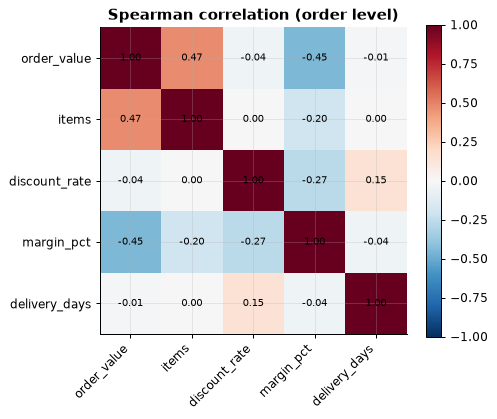

In [3]:
corr = pd.read_csv('data/outputs/statistics/correlation_spearman.csv', index_col=0)
fig, ax = plt.subplots(figsize=(5.5,4.5)); im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right'); ax.set_yticks(range(len(corr)), corr.index)
[ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8) for i in range(len(corr)) for j in range(len(corr))]
ax.set_title('Spearman correlation (order level)'); fig.colorbar(im); plt.show()

## Hypothesis tests
For each: hypothesis, H0/H1, metric, method, result, interpretation, limitation.

In [4]:
for t in st['tests']:
    p = t.get('p_value', t.get('p_value_mannwhitney'))
    print('='*90); print(t['name']); print('  H0:', t['h0']); print('  H1:', t['h1']); print('  Metric:', t['metric'], '| Method:', t['method'])
    extra = {k: round(float(v), 3) for k, v in t.items() if k.startswith(('group_a_m','group_b_m','group_a_r','group_b_r','rho','z','h_stat')) and v is not None}
    print('  Result:', extra, '| p =', f'{float(p):.3g}', '->', 'reject H0' if t['significant'] else 'fail to reject H0')

Deep discount (>=15%) vs low discount (<15%) - order value
  H0: Median order value is the same for both groups.
  H1: Median order value differs.
  Metric: Order net value (INR) | Method: Mann-Whitney U (non-normal data) + Welch t-test on log(order value)
  Result: {'group_a_median': 2344.2, 'group_b_median': 3212.56} | p = 1.23e-66 -> reject H0
Return rate: Marketplace vs Website
  H0: Return rates are equal.
  H1: Return rates differ.
  Metric: Returned lines / total lines | Method: Two-proportion z-test
  Result: {'group_a_rate_pct': 10.703, 'group_b_rate_pct': 8.071, 'z': 10.925} | p = 0 -> reject H0
Loyalty members vs non-members - orders per customer
  H0: Distribution of orders per customer is the same.
  H1: Distributions differ.
  Metric: Orders per customer (2023-2025) | Method: Mann-Whitney U
  Result: {'group_a_mean': 7.912, 'group_b_mean': 5.426} | p = 5.61e-32 -> reject H0
Ticket resolution time vs CSAT
  H0: No monotonic association (rho = 0).
  H1: rho != 0.
  Metric: 

### Interpretation & limitations
* **Discount vs order value:** deep-discount orders are *smaller*. This can come from product mix (cheap items are discounted more), so it is not proof that discounts shrink baskets.
* **Marketplace vs Website returns:** a significant, sizeable gap, which justifies a seller/listing-quality review.
* **Loyalty members:** order more, but self-selection bias means membership may not *cause* the extra orders. A randomised invite test would be needed.
* **Resolution time vs CSAT:** a strong negative association that supports SLA investment.
* **Channel AOV:** with about 55k orders even tiny differences become 'significant'. Check the effect size (₹ gap) before acting.
* Data is synthetic, and no multiple-testing correction is applied (5 tests, so read borderline p-values with caution).